In [1]:
from src.dataset import load_dataset
from regression.probabilistic_rf_scoring import plot_pdf_with_true_target, plot_ranked_pdfs
from regression.PolynomialRegressor.polynomial_regression import PolynomialRegression
import matplotlib.pyplot as plt
import os
import joblib
from regression.probabilistic_rf_scoring import fit_best_pdf
import pandas as pd
plt.style.use("default")
from plot_style import set_plot_style
set_plot_style()

In [2]:
TRAIN_PATH_FULL="../../../../data/processed/full_train/train.csv"
TRAIN_PATH_SPLIT= "../../../../data/processed/split_85_15/train_85.csv"
TEST_PATH_SPLIT= "../../../../data/processed/split_85_15/test_15.csv"
OUTPUT_PATH= "../../../../output/polynomial_regression/model_target/"
MODEL_PATH="polynomial_regression_model_target.pkl"
RESIDUI_CSV="residui.csv"
ITERATIONS = 1000
TARGET_COL = "trq_target"
FEUTURE=["trq_measured","mgt","ias","oat","np_ng_ratio","pa"]
DEGREE = (1,2,3)

In [3]:
train_df = load_dataset(TRAIN_PATH_SPLIT)
test_df = load_dataset(TEST_PATH_SPLIT)

X_train = train_df[FEUTURE].values
y_train = train_df[TARGET_COL].values

X_test = test_df[FEUTURE].values
y_test = test_df[TARGET_COL].values


Degree  1
MAE: 0.1849696331955001
MSE: 0.0653116873993568
RMSE: 0.2555615139244499
R²: 0.9996772304016452


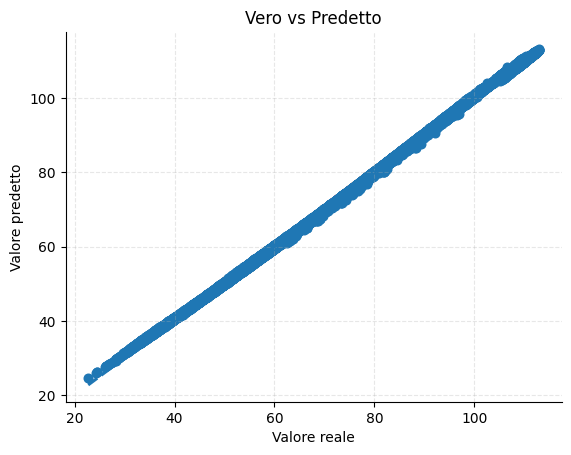


Degree  2
MAE: 0.021049430276294308
MSE: 0.001331155387866703
RMSE: 0.036485002231967906
R²: 0.9999934214455789


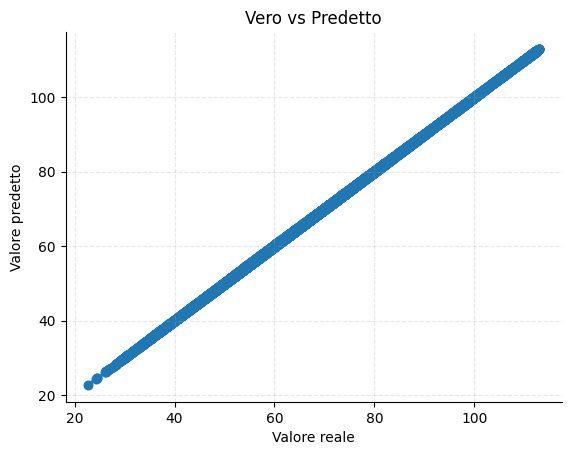


Degree  3
MAE: 0.017072748387306772
MSE: 0.0008022632573286177
RMSE: 0.028324252105371074
R²: 0.9999960352243273


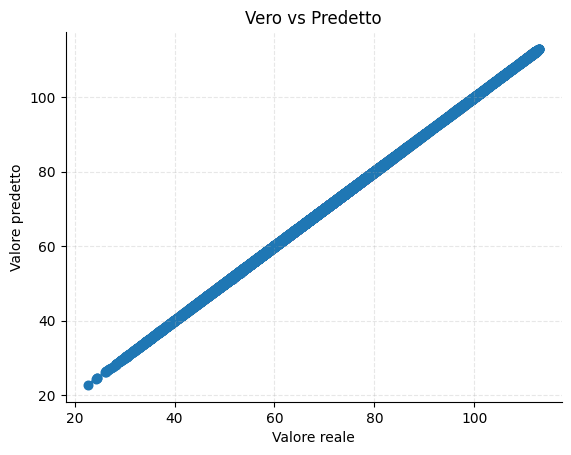

In [4]:
for degree in DEGREE:
    model = PolynomialRegression(degree=degree)
    model.fit(X_train, y_train)
    print("\n"+"Degree ", degree)
    model.evaluate_regression(X_test, y_test)

    y_pred = model.predict(X_test)
    y_pred = model.predict(X_test)

    plt.figure()
    plt.scatter(y_test, y_pred)
    plt.plot(
        [y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        linestyle="--"
    )
    plt.xlabel("Valore reale")
    plt.ylabel("Valore predetto")
    plt.title("Vero vs Predetto")
    plt.show()

In [4]:
train_full=load_dataset(TRAIN_PATH_FULL)
X_train_full = train_full[FEUTURE].values
y_train_full = train_full[TARGET_COL].values

In [5]:
model = PolynomialRegression(degree=3)
if os.path.exists(OUTPUT_PATH+MODEL_PATH):
    model= joblib.load(OUTPUT_PATH+MODEL_PATH)
else:
  model.fit(X_train, y_train)
  os.makedirs(OUTPUT_PATH, exist_ok=True)
  joblib.dump(model, OUTPUT_PATH + MODEL_PATH)

In [8]:
if os.path.exists( not OUTPUT_PATH+RESIDUI_CSV):
    model.compute_residuals(X_train,y_train,path=OUTPUT_PATH)

In [6]:
residui = load_dataset(OUTPUT_PATH + RESIDUI_CSV)

id=100
test_row = test_df.iloc[id]
test_x = test_row[FEUTURE].to_frame().T
test_y_true =(test_row["trq_measured"] / test_row["trq_target"] - 1) * 100
target_pred = model.predict(test_x)[0]
trq_margin_pred = (test_row["trq_measured"]/ target_pred - 1) * 100

rows = []
for m in range(ITERATIONS):
    residual = float(residui.sample(n=1)["residual"].iloc[0])
    rows.append({"trq_target_plus_residui": target_pred + residual})

distribution = pd.DataFrame(rows)
distribution["trq_margin"] = (test_row["trq_measured"] / distribution["trq_target_plus_residui"] - 1) * 100
distribution.head()

,trq_target_probability,trq_margin
0,72.131584,-6.005115
1,72.120687,-5.990912
2,72.163284,-6.046405
3,72.137846,-6.013273
4,72.136814,-6.011929


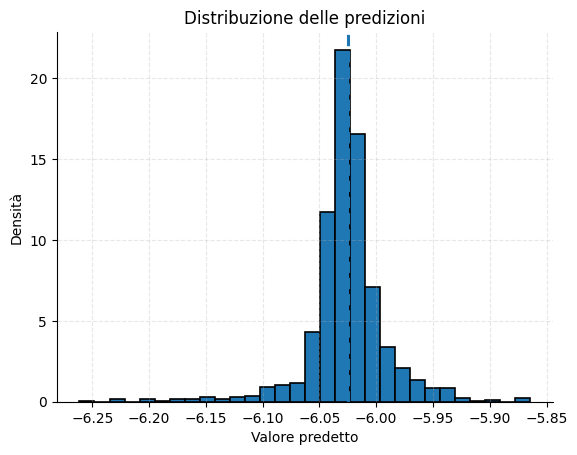

In [7]:
plt.figure()
plt.hist(distribution["trq_margin"], bins=30, density=True)
plt.axvline(trq_margin_pred, linestyle="--", label="Predizione puntuale")
plt.xlabel("Valore predetto")
plt.xlabel("Valore predetto")
plt.ylabel("Densità")
plt.title("Distribuzione delle predizioni")
plt.show()

In [8]:
best,results= fit_best_pdf(distribution["trq_margin"])

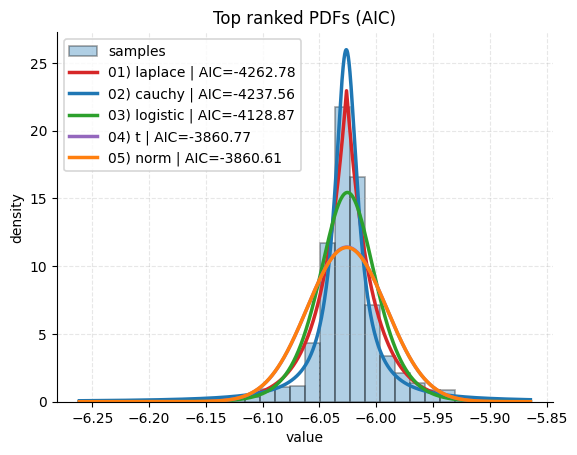

In [9]:
plot_ranked_pdfs(results,distribution["trq_margin"])

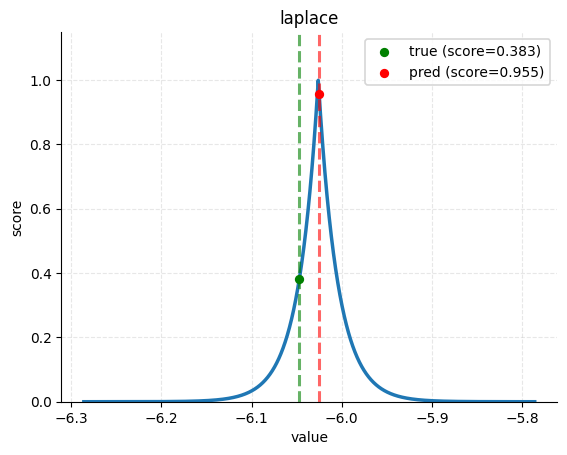

{'pdf_type': 'laplace',
 'true_target': -6.047048375117548,
 'prediction': -6.025137029482497,
 'score_true': 0.38287517594009507,
 'score_pred': 0.9554651530293782,
 'x_range': (-6.286092702300023, -5.786092702300023)}

In [10]:
plot_pdf_with_true_target(best["pdf_type"],best["pdf_args"],test_y_true,trq_margin_pred)

Predict testX

In [17]:
target_pred = model.predictAll(test_df,test_df["trq_margin"],FEATURES=FEUTURE,keep_cols=["mgt","ias","oat","np_ng_ratio","pa","faulty"])
target_pred.to_csv(OUTPUT_PATH+"pred_margin_test.csv")